# Задание
 Создайте систему компьютерного зрения, которая будет определять тип геометрической фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

Поменяйте количество нейронов в сети, используя следующие значения:
1.  Один слой 10 нейронов
2.  Один слой 100 нейронов
3.  Один слой 5000 нейронов.

Поменяйте активационную функцию в скрытых слоях с relu на linear.
Поменяйте размеры batch_size:
1.   10
2.   100
3.   1000

Выведите на экран получившиеся точности.
Всего должно получиться 18 комбинаций указанных параметров.
Создайте сравнительную таблицу по результатам проведенных тестов.

In [2]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Подключение модуля для работы с файлами
import os
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

In [3]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [4]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_light.zip

In [5]:
# Путь к директории с базой
base_dir = '/content/hw_light'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                   target_size=(img_height, img_width),
                                                    color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        elif patch == '3':
            y_train.append(1)
        else:
            y_train.append(2)

# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20, 1)
Размер массива y_train (302,)


# Проверка



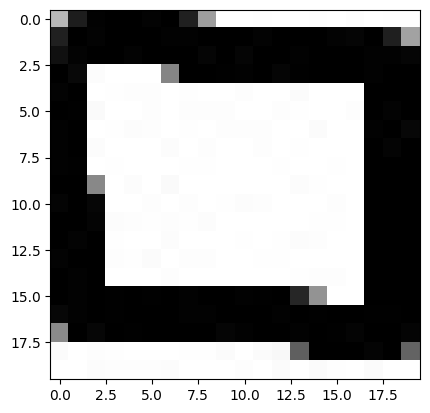

2


In [6]:
# Номер картинки
n = 50

# Отрисовка картинки
plt.imshow(x_train[n], cmap='gray')

# Вывод n-й картинки
plt.show()
# Вывод метки класса для n-го изображения
print(y_train[n])

In [7]:
# Изменение формы входных картинок с 20х20 на 400
x_train_n = x_train.reshape(x_train.shape[0], -1)
# Проверка результата
print(f'Форма обучающих данных: {x_train.shape} -> {x_train_n.shape}')

Форма обучающих данных: (302, 20, 20, 1) -> (302, 400)


In [8]:
# Нормализация входных картинок
# Преобразование x_train в тип float32 (числа с плавающей точкой) и нормализация
x_train_n = x_train_n.astype('float32') / 255.


In [9]:
# Задание константы количества распознаваемых классов
CLASS_COUNT = 3
# Преобразование ответов в формат one_hot_encoding
y_train_n = utils.to_categorical(y_train, CLASS_COUNT)
print(y_train_n.shape)
# Вывод примера одного выходного вектора
print(y_train_n[0])
# Вывод метки, соответствующей 126-му элементу
print(y_train_n[126])

(302, 3)
[0. 0. 1.]
[0. 1. 0.]


Слой из 10 нейронов batch_size=10 метод relu

In [53]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 10 нейронов с relu-активацией
model.add(Dense(10, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 10)             │         4,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,443 (642.36 KB)

 Trainable params: 164,443 (642.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5927 - loss: 0.9411
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7682 - loss: 0.6082
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7947 - loss: 0.5278
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7881 - loss: 0.5002
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3784
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8709 - loss: 0.3434
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8907 - loss: 0.3006
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9073 - loss: 0.2372
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9371 - loss: 0.2134
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9536 - loss: 0.1584
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9702 - loss: 0.1365
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8775

Слой из 10 нейронов batch_size=100 метод relu

In [57]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 10 нейронов с relu-активацией
model.add(Dense(10, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3974 - loss: 1.1035
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5430 - loss: 0.9531
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6026 - loss: 0.8684
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7219 - loss: 0.8083
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5397 - loss: 0.8378
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5430 - loss: 0.8127
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7252 - loss: 0.7150
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6854 - loss: 0.7283
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6954 - loss: 0.7239
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7318 - loss: 0.6788
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7881 - loss: 0.6319
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7384 - loss: 0.6473
E

Слой из 10 нейронов batch_size=1000 метод relu

In [58]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 10 нейронов с relu-активацией
model.add(Dense(10, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3179 - loss: 1.1376
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4603 - loss: 1.0548
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6325 - loss: 0.9640
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5166 - loss: 0.9215
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6821 - loss: 0.8276
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6821 - loss: 0.8324
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6921 - loss: 0.7632
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7483 - loss: 0.7390
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7450 - loss: 0.7026
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7550 - loss: 0.6728
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7914 - loss: 0.6171
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8046 - loss: 0.5936
Ep

создал слой из 100 нейронов метод relu

Слой из 100 нейронов batch_size=10 метод relu

In [56]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 100 нейронов с relu-активацией
model.add(Dense(100, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,803 (784.39 KB)

 Trainable params: 200,803 (784.39 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4636 - loss: 1.0645
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7152 - loss: 0.6926
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7616 - loss: 0.6245
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8179 - loss: 0.4996
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8245 - loss: 0.4629
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8642 - loss: 0.3740
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8940 - loss: 0.2896
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9404 - loss: 0.2175
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9073 - loss: 0.2244
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9735 - loss: 0.1259
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9603 - loss: 0.1183
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.97

Слой из 100 нейронов batch_size=100 метод relu

In [39]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 100 нейронов с relu-активацией
model.add(Dense(100, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3841 - loss: 1.3240
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6358 - loss: 0.8299
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6523 - loss: 0.7913
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6623 - loss: 0.7210
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6656 - loss: 0.7395
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7318 - loss: 0.6710
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6457 - loss: 0.7143
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7682 - loss: 0.6602
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6954 - loss: 0.6955
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8079 - loss: 0.5425
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8079 - loss: 0.5342
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8278 - loss: 0.4986
E

Слой из 100 нейронов batch_size=1000 метод relu

In [40]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 100 нейронов с relu-активацией
model.add(Dense(100, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2649 - loss: 1.2490
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3377 - loss: 1.4494
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6391 - loss: 0.8559
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5530 - loss: 0.9711
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5662 - loss: 0.8850
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7285 - loss: 0.7084
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7483 - loss: 0.6835
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7119 - loss: 0.7016
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7450 - loss: 0.6568
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7748 - loss: 0.6166
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7947 - loss: 0.6069
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7616 - loss: 0.5943
Epo

Слой из 5000 нейронов batch_size=10 метод relu

In [59]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 5000 нейронов с relu-активацией
model.add(Dense(5000, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 5000)           │     2,005,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 3)              │        15,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,180,403 (8.32 MB)

 Trainable params: 2,180,403 (8.32 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6291 - loss: 0.8744
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7914 - loss: 0.4691
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8576 - loss: 0.3787
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8907 - loss: 0.3022
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8775 - loss: 0.3433
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9305 - loss: 0.2041
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9636 - loss: 0.1305
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9437 - loss: 0.1520
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9470 - loss: 0.1305
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9801 - loss: 0.0750
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9801 - loss: 0.0548
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accu

Слой из 5000 нейронов batch_size=100 метод relu

In [42]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(408, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 5000 нейронов с relu-активацией
model.add(Dense(5000, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3775 - loss: 1.7178
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4967 - loss: 1.1187
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5530 - loss: 0.8548
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6722 - loss: 0.7067
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8278 - loss: 0.5894
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8576 - loss: 0.4951
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8079 - loss: 0.5003
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8576 - loss: 0.4213
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8841 - loss: 0.3388
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9040 - loss: 0.2647
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8576 - loss: 0.3047
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8775 - loss: 0.3048
E

Слой из 5000 нейронов batch_size=1000 метод relu

In [43]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(408, input_dim=400, activation='relu'))
# Добавление полносвязного слоя на 5000 нейронов с relu-активацией
model.add(Dense(5000, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3311 - loss: 1.1578
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5265 - loss: 2.6302
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3311 - loss: 1.5371
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6490 - loss: 0.7963
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5695 - loss: 1.0332
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7185 - loss: 0.9014
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7417 - loss: 0.7601
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8146 - loss: 0.6398
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7815 - loss: 0.6484
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7152 - loss: 0.6629
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7881 - loss: 0.5769
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8775 - loss:

Слой из 10 нейронов batch_size=10 метод linear

In [60]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 10 нейронов с linear-активацией
model.add(Dense(10, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 10)             │         4,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,443 (642.36 KB)

 Trainable params: 164,443 (642.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4669 - loss: 1.6701
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5795 - loss: 1.1897
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7351 - loss: 0.6964
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7020 - loss: 0.7543
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7715 - loss: 0.5848
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7815 - loss: 0.5412
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7947 - loss: 0.5327
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8146 - loss: 0.4973
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7318 - loss: 0.6515
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7318 - loss: 0.6643
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8411 - loss: 0.4895
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8411

Слой из 10 нейронов batch_size=100 метод linear

In [45]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 10 нейронов с linear-активацией
model.add(Dense(10, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3974 - loss: 2.1416
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5166 - loss: 1.1303
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5364 - loss: 1.2413
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5993 - loss: 1.3019
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6523 - loss: 0.8768
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5298 - loss: 1.3945
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6954 - loss: 0.8751
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6722 - loss: 0.9198
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6689 - loss: 0.7878
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7417 - loss: 0.6781
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7219 - loss: 0.8818
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7649 - loss: 0.7407
E

Слой из 10 нейронов batch_size=1000 метод linear

In [46]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 10 нейронов с linear-активацией
model.add(Dense(10, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3377 - loss: 1.3744
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3377 - loss: 4.9811
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3046 - loss: 3.1503
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3311 - loss: 3.0332
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4338 - loss: 1.7126
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4470 - loss: 1.2107
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3775 - loss: 1.5262
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4967 - loss: 1.9378
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.9831
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4702 - loss: 1.6073
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3444 - loss: 1.3103
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5364 - loss: 0.9403
Epo

Слой из 100 нейронов batch_size=10 метод linear

In [61]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 100 нейронов с linear-активацией
model.add(Dense(100, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_99 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,803 (784.39 KB)

 Trainable params: 200,803 (784.39 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5629 - loss: 1.5709
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6987 - loss: 0.8528
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7086 - loss: 0.7407
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7219 - loss: 0.7073
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7450 - loss: 0.6244
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8013 - loss: 0.5557
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7616 - loss: 0.5785
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7980 - loss: 0.4933
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7616 - loss: 0.6345
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7815 - loss: 0.4920
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8411 - loss: 0.4130
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8079

Слой из 100 нейронов batch_size=100 метод linear

In [48]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 100 нейронов с linear-активацией
model.add(Dense(100, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3775 - loss: 3.0520
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4834 - loss: 1.4985
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5563 - loss: 1.0478
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7119 - loss: 0.9106
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5927 - loss: 1.0271
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5596 - loss: 0.9718
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6026 - loss: 1.3183
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6722 - loss: 0.8979
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6854 - loss: 0.7454
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7583 - loss: 0.6794
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6159 - loss: 0.9676
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6689 - loss: 0.7591
E

Слой из 100 нейронов batch_size=1000 метод linear

In [49]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 100 нейронов с linear-активацией
model.add(Dense(100, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2682 - loss: 1.4064
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3311 - loss: 5.5987
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3411 - loss: 4.2500
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3444 - loss: 2.6436
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5099 - loss: 1.0684
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4868 - loss: 2.0379
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4570 - loss: 2.3157
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5166 - loss: 1.5170
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6523 - loss: 0.7849
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5795 - loss: 1.0351
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5166 - loss: 1.3504
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6258 - loss: 1.2776
Epo

Слой из 5000 нейронов

Слой из 5000 нейронов batch_size=10 метод linear

In [62]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 5000 нейронов с linear-активацией
model.add(Dense(5000, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())
model.fit(x_train_n, y_train_n, batch_size=10, epochs=15, verbose=1)

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_102 (Dense)               │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 5000)           │     2,005,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 3)              │        15,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,180,403 (8.32 MB)

 Trainable params: 2,180,403 (8.32 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.4669 - loss: 3.8812
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6755 - loss: 0.9396
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7483 - loss: 0.6211
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7483 - loss: 0.6242
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7252 - loss: 0.6913
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7947 - loss: 0.5525
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8079 - loss: 0.5356
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8146 - loss: 0.4771
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6921 - loss: 0.7360
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7881 - loss: 0.5306
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8113 - loss: 0.5364
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accu

Слой из 5000 нейронов batch_size=100 метод linear

In [51]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 5000 нейронов с linear-активацией
model.add(Dense(5000, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=100, epochs=15, verbose=1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4768 - loss: 4.6103
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5397 - loss: 4.6545
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3940 - loss: 5.4149
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5232 - loss: 2.0639
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5331 - loss: 2.4393
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4834 - loss: 1.9967
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6358 - loss: 1.1942
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7152 - loss: 1.2144
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6921 - loss: 0.9364
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7020 - loss: 0.7043
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6689 - loss: 0.8067
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5132 - loss: 1.2248
E

Слой из 5000 нейронов batch_size=1000 метод linear

In [52]:
# Создание последовательной модели
model = Sequential()
model.add(Dense(400, input_dim=400, activation='linear'))
# Добавление полносвязного слоя на 5000 нейронов с linear-активацией
model.add(Dense(5000, activation='linear'))
model.add(Dense(CLASS_COUNT, activation='softmax'))
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=1000, epochs=15, verbose=1)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3278 - loss: 1.1246
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5298 - loss: 4.8058
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5232 - loss: 3.5612
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3311 - loss: 7.2782
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4007 - loss: 2.8889
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.4702 - loss: 2.4695
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6291 - loss: 1.8610
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.4801 - loss: 3.0294
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5563 - loss: 2.1072
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7185 - loss: 0.8189
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5199 - loss: 1.1521
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5232 - loss: